In [1]:
import langchain
langchain.__version__

'1.2.6'

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

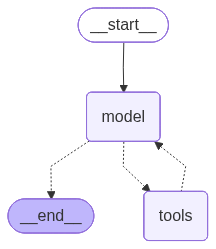

In [11]:
from langchain.agents import create_agent

def get_weather (city:str) -> str:
    """ Get the weather for a city """  # ValueError: Function must have a docstring if description not provided.
    return f"The weather in {city} is sunny"

agent = create_agent(
    model ="gpt-5",
    tools = [get_weather],
    system_prompt= "You are a helpful assistant"
)
agent


In [16]:
response = agent.invoke({"messages" :[{"role" :"user" , "content" : "What is the weather like in New York?"}] })
response["messages"]

[HumanMessage(content='What is the weather like in New York?', additional_kwargs={}, response_metadata={}, id='3322ba38-1e44-4eef-804d-8233f8e01c25'),
 AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 152, 'prompt_tokens': 143, 'total_tokens': 295, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 128, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-D0gW8I7KqoDrj2dsWJxkjfp6Wz4JB', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019be3f1-6cd1-7a21-96c2-3a5d722cddd2-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'New York'}, 'id': 'call_VhbKOggsDois1dvAfQK5ZfkN', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 143, 'output_tokens': 152,

In [17]:
agent.invoke({"messages" : "What is the weather in New York ?"})

{'messages': [HumanMessage(content='What is the weather in New York ?', additional_kwargs={}, response_metadata={}, id='77115ca7-1387-4b48-adea-3d985d051f92'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 88, 'prompt_tokens': 142, 'total_tokens': 230, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 64, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-D0gXAwdqOud7Hd6E5onycSCiTpCUp', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019be3f2-6320-7b00-84a4-8020a45c75f3-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'New York'}, 'id': 'call_PuhcY5bsDBkCCB86TOo5ENNB', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 142, 'output_token

### Model Integration 

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GOOGLE_API_KEY"]=os.getenv("GOOGLE_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [2]:
from langchain.chat_models import init_chat_model
model=init_chat_model("gpt-4.1")
model

ChatOpenAI(profile={'max_input_tokens': 1047576, 'max_output_tokens': 32768, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x000001EC30175A90>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000001EC3027C530>, root_client=<openai.OpenAI object at 0x000001EC111B1F40>, root_async_client=<openai.AsyncOpenAI object at 0x000001EC301CCB30>, model_name='gpt-4.1', model_kwargs={}, openai_api_key=SecretStr('**********'), stream_usage=True)

In [3]:
response=model.invoke("Hello How are you?")
response

AIMessage(content="Hello! I'm just a virtual assistant, but I'm here and ready to help. How can I assist you today?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 12, 'total_tokens': 35, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_1a2c4a5ede', 'id': 'chatcmpl-D0gjtk4JhUZiM8oVCS2dLikQtflwR', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019be3fe-6bab-70e0-a5cc-02384d39b2d2-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 12, 'output_tokens': 23, 'total_tokens': 35, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

### Google Gemini Model Integration

In [4]:
import os
from langchain.chat_models import init_chat_model

os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")

model = init_chat_model("google_genai:gemini-2.5-flash")
response = model.invoke("Why do parrots talk?")
response.content

'Parrots\' ability to mimic human speech is one of their most captivating and unique traits. It\'s a combination of several factors:\n\n1.  **Unique Vocal Anatomy (The "How"):**\n    *   Unlike humans who use a larynx, birds have a **syrinx**, which is located at the base of the trachea. Parrots have an exceptionally flexible and complex syrinx, allowing them to produce a wide range of sounds, pitches, and tones.\n    *   They also have a thick, muscular tongue, which gives them more control over the shape of their oral cavity, further enabling them to articulate sounds that resemble human vowels and consonants.\n\n2.  **Social Animals & Mimicry (The "Why" in the Wild):**\n    *   Parrots are highly social flock animals in the wild. Communication is vital for their survival and social cohesion.\n    *   They naturally mimic sounds from their environment – other birds, animals, and even natural sounds – to communicate with their flock, identify themselves, warn of predators, and strengt

In [5]:
import os
from langchain_google_genai import ChatGoogleGenerativeAI
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite")
response = model.invoke("Why do parrots talk?")
response

AIMessage(content='Parrots talk for a variety of fascinating reasons, and it\'s a complex behavior driven by both innate abilities and learned responses. Here\'s a breakdown of the main factors:\n\n**1. Social Bonding and Communication:**\n\n* **Flock Calls:** In the wild, parrots are highly social creatures that live in flocks. They use vocalizations, including mimicry, to maintain contact with their group, signal danger, find food sources, and reinforce social bonds. Talking to their flock members is crucial for their survival and well-being.\n* **Reinforcing Relationships:** In captivity, a parrot\'s "talking" is often directed at their human companions, who become their surrogate flock. They are trying to communicate with and bond with you, their primary social group. By mimicking your words, they are essentially saying, "I see you, I hear you, and I\'m part of your group."\n\n**2. Intelligence and Cognitive Abilities:**\n\n* **Advanced Vocal Learning:** Parrots are among a select 